In [31]:
import random
import os, time, json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_recall_fscore_support
)

import matplotlib.pyplot as plt
import seaborn as sns


k = 20 

# PATHS
PROJECT_ROOT = Path("/Users/syedadnanahmad/Downloads/AI_TUMOUR_detection")
EMB_ROOT     = PROJECT_ROOT / "embeddings"
IDX_CSV      = PROJECT_ROOT / "notebooks" / "slide_index.csv"
MODEL_DIR    = PROJECT_ROOT / "models"
RESULTS_DIR  = PROJECT_ROOT / "results"

MODEL_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# DEVICE
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

df_index = pd.read_csv(IDX_CSV)


Device: mps


In [32]:
OSCC_CLASSES = ["wdoscc", "mdoscc", "pdoscc"]
NORMAL_CLASS = ["normal"]

def make_stage1_df(df):
    mask = df["class"].isin(OSCC_CLASSES + NORMAL_CLASS)
    df2 = df[mask].copy().reset_index(drop=True)
    df2["binary_label"] = df2["class"].apply(lambda c: 1 if c in OSCC_CLASSES else 0)
    return df2

df_stage1 = make_stage1_df(df_index)


In [33]:
class BalancedBinarySlideDataset(Dataset):
    def __init__(self, df, split, k=K):
        self.k = k
        self.rows = df[df["split"]==split].reset_index(drop=True)
        self.items = []
        for _, r in self.rows.iterrows():
            slide = r["slide_id"]; cls = r["class"]
            label = 1 if cls in OSCC_CLASSES else 0
            emb_path = EMB_ROOT / split / cls / f"{slide}.npy"
            if emb_path.exists():
                emb_arr = np.load(emb_path).astype(np.float32)   # in memory load per item later
                # store path only to avoid huge memory usage
                self.items.append({"emb_path": emb_path, "label": label, "slide_id": slide, "n_patches": emb_arr.shape[0]})
        assert len(self.items)>0, "No items"

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        it = self.items[idx]
        arr = np.load(it["emb_path"]).astype(np.float32)   # (N,D)
        n = arr.shape[0]
        if n >= self.k:
            sel = np.random.choice(n, self.k, replace=False)
        else:
            sel = np.random.choice(n, self.k, replace=True)
        sampled = arr[sel]               # (k, D)
        sampled = torch.from_numpy(sampled)
        label = torch.tensor(it["label"], dtype=torch.long)
        return {"emb": sampled, "label": label, "slide_id": it["slide_id"]}


In [34]:
train_ds = BalancedBinarySlideDataset(df_stage1, "train", k=K)
val_ds   = BalancedBinarySlideDataset(df_stage1, "val",   k=K)
test_ds  = BalancedBinarySlideDataset(df_stage1, "test",  k=K)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, collate_fn=lambda x: x[0], num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False, collate_fn=lambda x: x[0], num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False, collate_fn=lambda x: x[0], num_workers=0)
print("Train/Val/Test:", len(train_ds), len(val_ds), len(test_ds))


Train/Val/Test: 118 118 119


In [35]:
class AttentionMIL(nn.Module):
    def __init__(self, emb_dim=512, hidden_dim=256, dropout=0.4):
        super().__init__()
        self.V = nn.Linear(emb_dim, hidden_dim)
        self.U = nn.Linear(emb_dim, hidden_dim)
        self.w = nn.Linear(hidden_dim, 1)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, emb_dim//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim//2, 2)
        )
    def forward(self, H):
        Vh = torch.tanh(self.V(H))
        Uh = torch.sigmoid(self.U(H))
        A  = self.w(Vh * Uh).squeeze(1)
        attn = torch.softmax(A, dim=0)
        agg = torch.sum(attn.unsqueeze(1) * H, dim=0)
        logits = self.classifier(agg)
        return logits.unsqueeze(0)


In [36]:
model = AttentionMIL().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-5)
class_weights = torch.tensor([3.0,1.0], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

best_f1 = -1; patience=6; no_imp=0
TH = 0.65

def train_epoch_sampled(model, loader):
    model.train()
    losses, y_true, y_pred = [], [], []
    for batch in loader:
        emb = batch["emb"].to(device)      # (K, D)
        label = batch["label"].to(device)
        optimizer.zero_grad()
        logits = model(emb)
        loss = criterion(logits, label.unsqueeze(0))
        loss.backward(); optimizer.step()
        losses.append(loss.item())
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()[0]
        pred = 1 if probs[1] > TH else 0
        y_pred.append(pred); y_true.append(int(label))
    return np.mean(losses), accuracy_score(y_true,y_pred), precision_recall_fscore_support(y_true,y_pred,average='macro',zero_division=0)[2]

def val_epoch_sampled(model, loader):
    model.eval()
    losses, y_true, y_pred = [], [], []
    with torch.no_grad():
        for batch in loader:
            emb = batch["emb"].to(device)
            label = batch["label"].to(device)
            logits = model(emb)
            loss = criterion(logits, label.unsqueeze(0)); losses.append(loss.item())
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
            pred = 1 if probs[1] > TH else 0
            y_pred.append(pred); y_true.append(int(label))
    return np.mean(losses), accuracy_score(y_true,y_pred), precision_recall_fscore_support(y_true,y_pred,average='macro',zero_division=0)[2]

# training loop
for epoch in range(1,41):
    tr_loss, tr_acc, tr_f1 = train_epoch_sampled(model, train_loader)
    va_loss, va_acc, va_f1 = val_epoch_sampled(model, val_loader)
    print(f"Epoch {epoch}: Val F1={va_f1:.3f}, Val Acc={va_acc:.3f}")
    if va_f1 > best_f1:
        best_f1 = va_f1; no_imp = 0
        torch.save(model.state_dict(), MODEL_DIR/"stage1_balanced_best.pth")
    # else:
    #     no_imp += 1
    #     if no_imp >= patience:
    #         print("Early stopping."); break


Epoch 1: Val F1=0.468, Val Acc=0.881
Epoch 2: Val F1=0.468, Val Acc=0.881
Epoch 3: Val F1=0.468, Val Acc=0.881
Epoch 4: Val F1=0.468, Val Acc=0.881
Epoch 5: Val F1=0.468, Val Acc=0.881
Epoch 6: Val F1=0.468, Val Acc=0.881
Epoch 7: Val F1=0.468, Val Acc=0.881
Epoch 8: Val F1=0.468, Val Acc=0.881
Epoch 9: Val F1=0.468, Val Acc=0.881
Epoch 10: Val F1=0.468, Val Acc=0.881
Epoch 11: Val F1=0.468, Val Acc=0.881
Epoch 12: Val F1=0.537, Val Acc=0.890
Epoch 13: Val F1=0.468, Val Acc=0.881
Epoch 14: Val F1=0.699, Val Acc=0.915
Epoch 15: Val F1=0.742, Val Acc=0.924
Epoch 16: Val F1=0.817, Val Acc=0.941
Epoch 17: Val F1=0.861, Val Acc=0.949
Epoch 18: Val F1=0.880, Val Acc=0.958
Epoch 19: Val F1=0.880, Val Acc=0.958
Epoch 20: Val F1=0.888, Val Acc=0.958
Epoch 21: Val F1=0.831, Val Acc=0.941
Epoch 22: Val F1=0.914, Val Acc=0.966
Epoch 23: Val F1=0.907, Val Acc=0.966
Epoch 24: Val F1=0.919, Val Acc=0.966
Epoch 25: Val F1=0.937, Val Acc=0.975
Epoch 26: Val F1=0.957, Val Acc=0.983
Epoch 27: Val F1=0.93

=== Stage-1 Balanced TEST ===
              precision    recall  f1-score   support

      normal       1.00      0.71      0.83        14
        oscc       0.96      1.00      0.98       105

    accuracy                           0.97       119
   macro avg       0.98      0.86      0.91       119
weighted avg       0.97      0.97      0.96       119

Confusion matrix:
 [[ 10   4]
 [  0 105]]


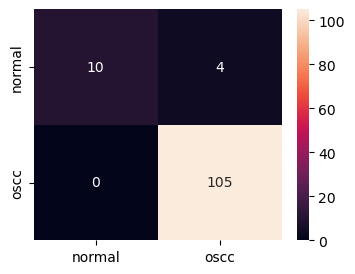

In [37]:
from sklearn.metrics import classification_report, confusion_matrix
model.load_state_dict(torch.load(MODEL_DIR/"stage1_balanced_best.pth", map_location=device))
model.to(device); model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for batch in test_loader:
        emb = batch["emb"].to(device)
        label = int(batch["label"])
        logits = model(emb)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred = 1 if probs[1] > TH else 0
        y_true.append(label); y_pred.append(pred)

print("=== Stage-1 Balanced TEST ===")
print(classification_report(y_true, y_pred, target_names=["normal","oscc"], zero_division=0))
cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)
# plot
import seaborn as sns, matplotlib.pyplot as plt
plt.figure(figsize=(4,3)); sns.heatmap(cm, annot=True, fmt="d", xticklabels=["normal","oscc"], yticklabels=["normal","oscc"]); plt.show()
